# Van Hove Correlation Function and Dynamic Heterogeneity

The self part of the Van Hove correlation function is defined as

$$G_s(r, \tau) = \frac{1}{N} \sum_{t=0}^{N-\tau} \delta\bigl(r - |\mathbf{r}(t+\tau) - \mathbf{r}(t)|\bigr)$$

and gives the probability density of finding a displacement magnitude $r$ at
lag time $\tau$. For free Brownian motion $G_s$ is a Maxwell-Boltzmann
distribution (Gaussian in Cartesian components). Deviations indicate
non-Fickian behaviour: a sharp central peak with a heavy tail signals
caging, where the particle rattles in a cage and occasionally escapes; a
double peak or elevated high-$r$ shoulder is the hallmark of hopping
diffusion. The non-Gaussian parameter $\alpha_2$ quantifies these deviations
through the fourth moment of the displacement distribution.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
DATA_DIR = os.path.abspath('../data')
FIG_DIR  = os.path.abspath('../figures')
os.makedirs(FIG_DIR, exist_ok=True)


In [2]:
import matplotlib as mpl
mpl.rcParams.update({
    'font.family'      : 'serif',
    'font.size'        : 11,
    'axes.labelsize'   : 12,
    'axes.titlesize'   : 12,
    'legend.fontsize'  : 10,
    'xtick.labelsize'  : 10,
    'ytick.labelsize'  : 10,
    'figure.dpi'       : 150,
    'savefig.dpi'      : 300,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.linewidth'   : 0.8,
    'grid.alpha'       : 0.3,
    'grid.linewidth'   : 0.5,
})

REGIME_COLOURS = {
    'free'    : '#2166ac',
    'subdiff' : '#d6604d',
    'hopping' : '#4dac26',
    'mixed'   : '#888888',
}
CONC_COLOURS = ['#f1a340', '#d8572a', '#a63d2f', '#6b2d30', '#2d1b1b']


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from src.io_utils import load_all_trajectories, DATA_DIR
from src.van_hove import van_hove_self, non_gaussian_parameter, alpha2_vs_lag
from src.trajectory_analysis import unwrap_trajectory

trajs, meta = load_all_trajectories(DATA_DIR)

# Three representative conditions
conditions = {
    'free'   : (0.00, 0.0),
    'subdiff': (0.50, 0.0),
    'hopping': (0.30, 6.0),
}

# Pool displacements from all 8 runs for each condition
pooled_trajs = {}
for label, (conc, charge) in conditions.items():
    dfs = [trajs[(conc, charge, run_id)] for run_id in range(8)
           if (conc, charge, run_id) in trajs]
    pooled_trajs[label] = dfs
    print(f'{label}: {len(dfs)} runs loaded.')


Loading trajectories: 100%|████████████████| 160/160 [00:01<00:00, 126.79file/s]

Loaded 160 trajectories across 20 conditions.
free: 8 runs loaded.
subdiff: 8 runs loaded.
hopping: 8 runs loaded.


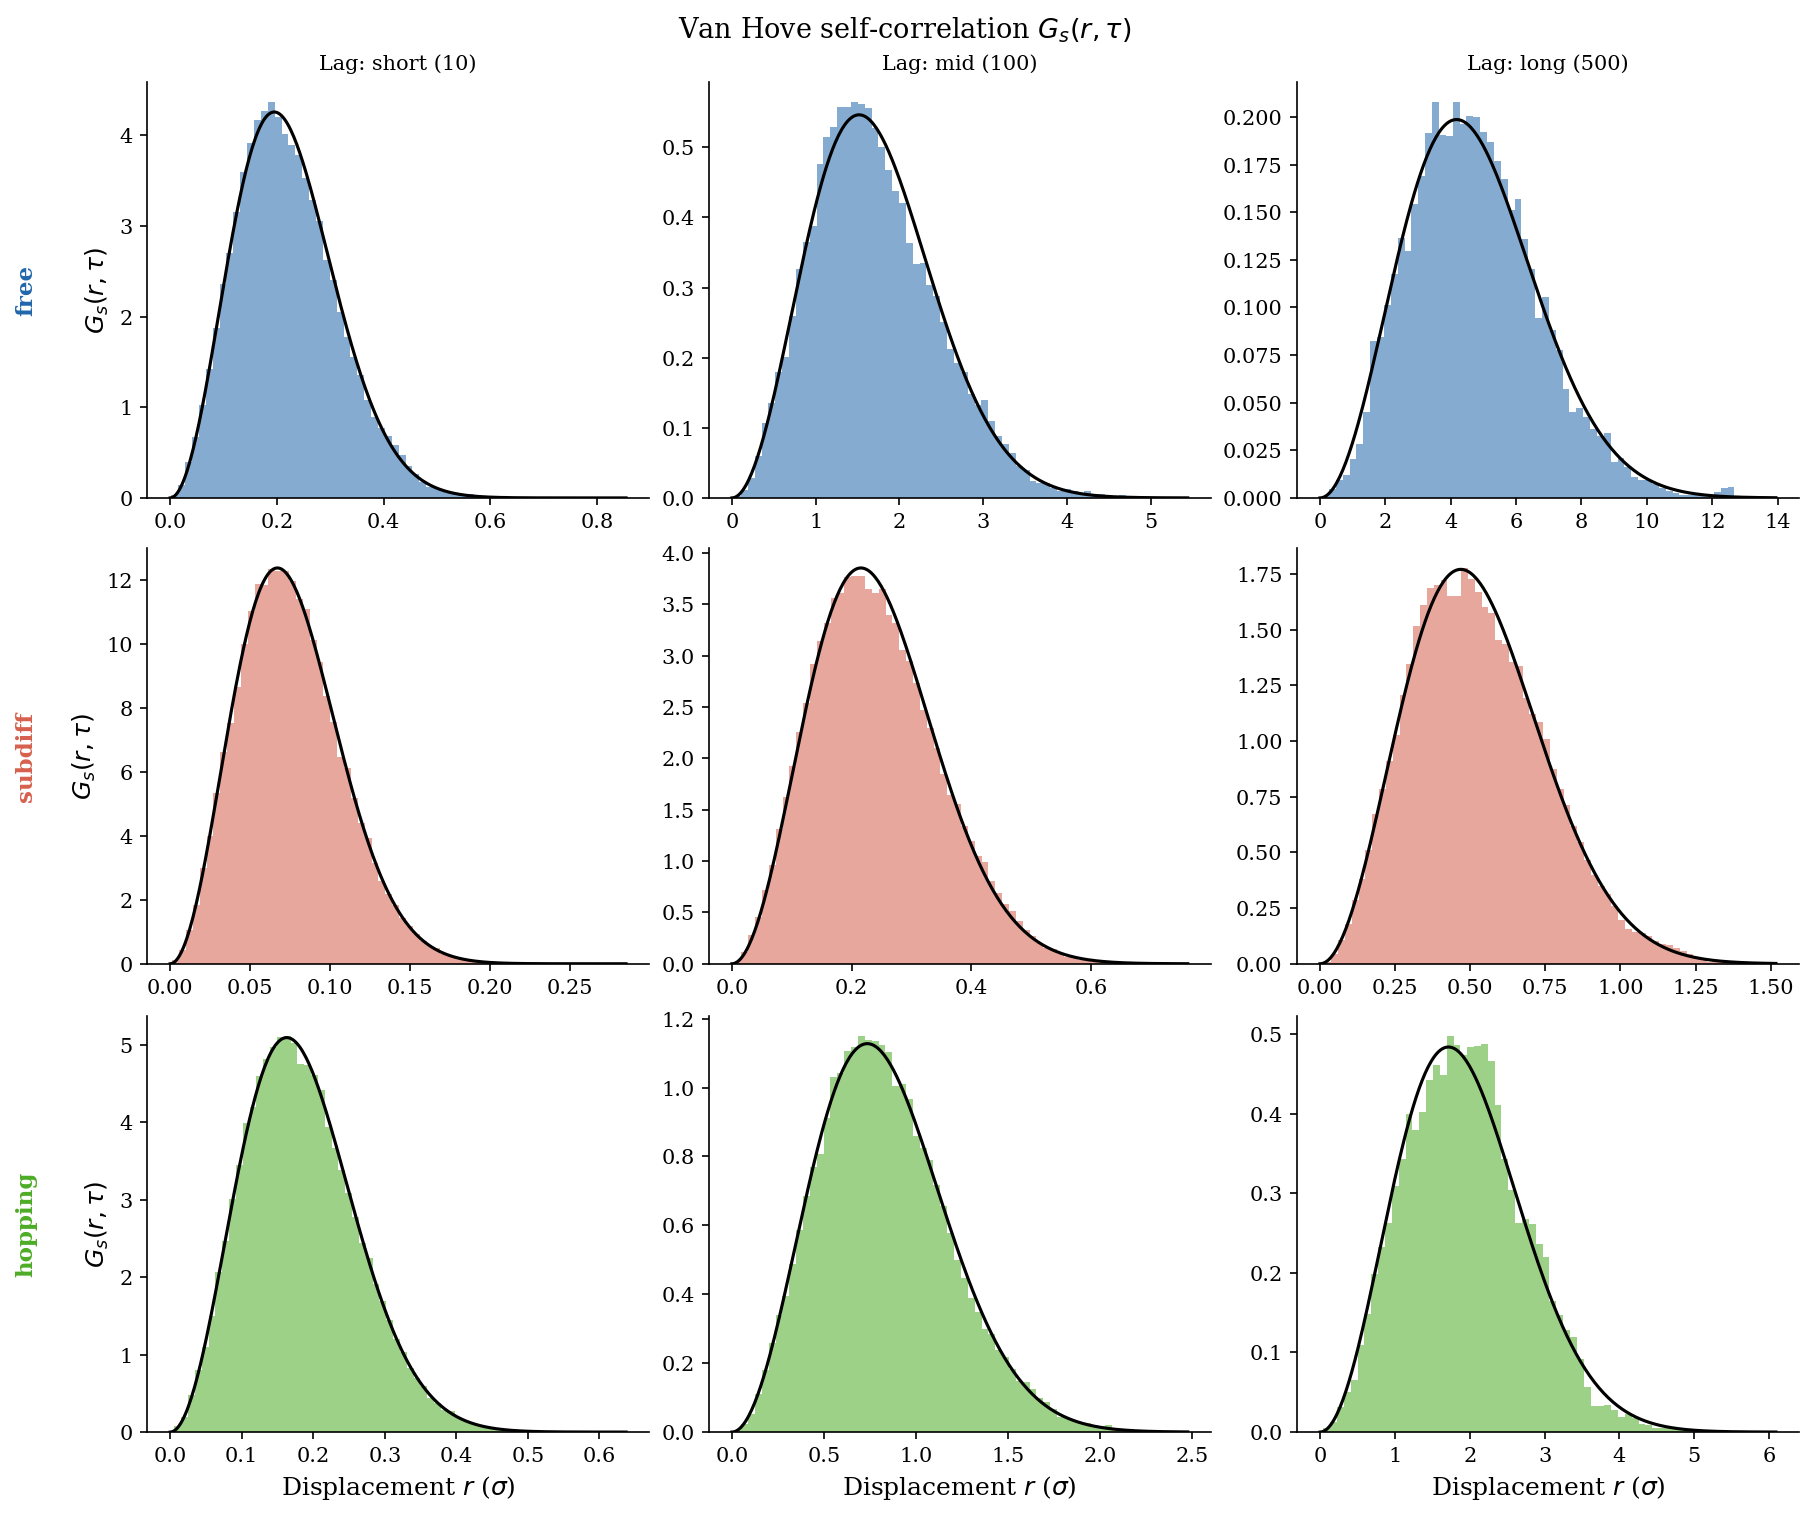

Saved: figures/03_van_hove_gallery.png


In [4]:
# Figure 03a: Van Hove gallery (3 regimes x 3 lag times)
lag_times = {'short (10)': 10, 'mid (100)': 100, 'long (500)': 500}
regime_order = ['free', 'subdiff', 'hopping']

fig, axes = plt.subplots(3, 3, figsize=(12, 10), constrained_layout=True)

for row_i, regime in enumerate(regime_order):
    dfs = pooled_trajs[regime]
    colour = REGIME_COLOURS[regime]

    for col_j, (lag_label, lag) in enumerate(lag_times.items()):
        ax = axes[row_i, col_j]

        # Pool displacements across runs at this lag
        all_disps = []
        for df in dfs:
            r = unwrap_trajectory(df)
            n = len(r)
            if lag < n:
                disp = np.sqrt(np.sum((r[lag:] - r[:n - lag])**2, axis=1))
                all_disps.append(disp)

        if not all_disps:
            continue
        disps = np.concatenate(all_disps)

        ax.hist(disps, bins=60, density=True, alpha=0.55,
                color=colour, label='data')

        # Gaussian overlay: fit mean and std of displacements
        mu_fit  = disps.mean()
        sig_fit = disps.std()
        r_plot  = np.linspace(0, disps.max() * 1.1, 300)
        # Maxwell-Boltzmann approximation
        from scipy.stats import maxwell
        _, scale = maxwell.fit(disps, floc=0)
        ax.plot(r_plot, maxwell.pdf(r_plot, scale=scale),
                'k-', lw=1.5, label='Gaussian fit')

        # Annotate alpha_2 if significant
        alpha2 = non_gaussian_parameter(dfs[0], lag)
        if alpha2 > 0.15:
            ax.text(0.62, 0.88, f'alpha_2 = {alpha2:.2f}',
                    transform=ax.transAxes, fontsize=8,
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

        ax.set_xlabel(r'Displacement $r$ ($\sigma$)' if row_i == 2 else '')
        ax.set_ylabel(r'$G_s(r,\tau)$' if col_j == 0 else '')
        if row_i == 0:
            ax.set_title(f'Lag: {lag_label}', fontsize=10)

    axes[row_i, 0].text(-0.22, 0.5, regime, transform=axes[row_i, 0].transAxes,
                         fontsize=11, va='center', ha='right', rotation=90,
                         color=colour, fontweight='bold')

fig.suptitle(r'Van Hove self-correlation $G_s(r,\tau)$', fontsize=13)
plt.savefig(f'{FIG_DIR}/03_van_hove_gallery.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/03_van_hove_gallery.png")


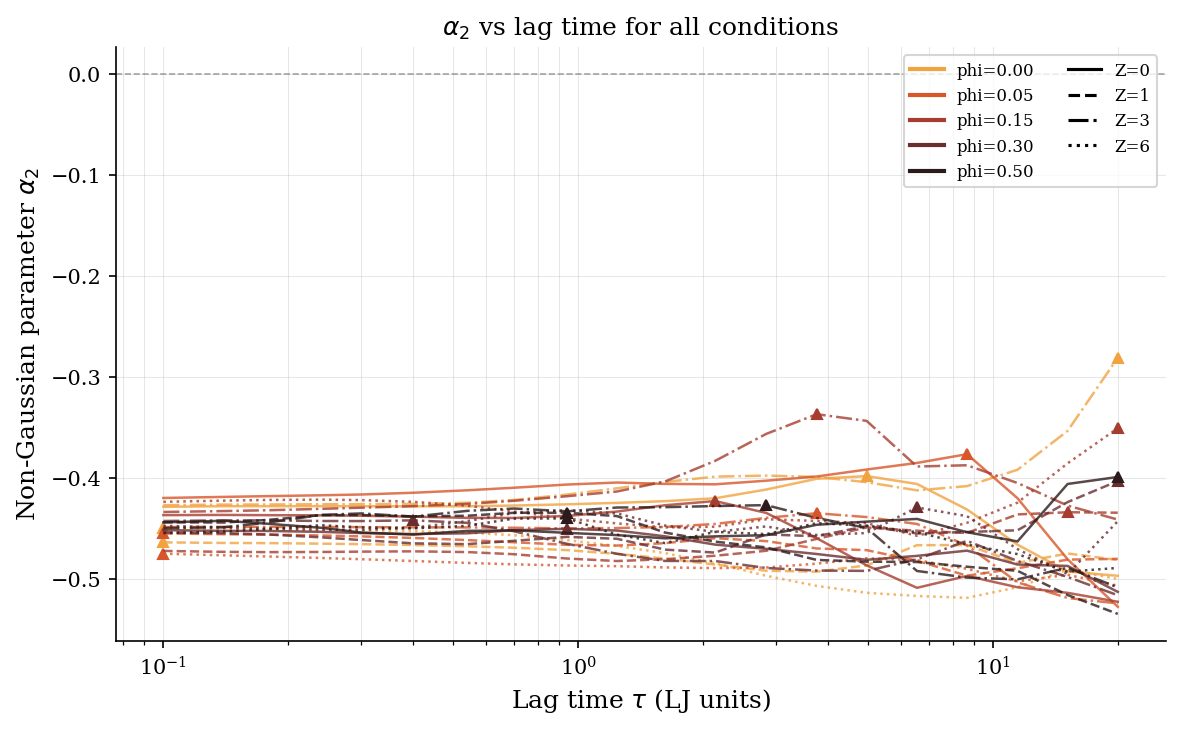

Saved: figures/03_alpha2_vs_lag.png


In [5]:
# Figure 03b: alpha_2 vs lag time for all 20 conditions
import numpy as np

concs   = sorted({k[0] for k in trajs})
charges = sorted({k[1] for k in trajs})
lag_values = np.unique(np.round(np.logspace(np.log10(5), np.log10(1000), 20)).astype(int))

linestyles = ['-', '--', '-.', ':']

fig, ax = plt.subplots(figsize=(8, 5))
ax.axhline(0.0, color='grey', ls='--', lw=0.8, alpha=0.7, label='Gaussian reference')

for idx_c, conc in enumerate(concs):
    for idx_q, charge in enumerate(charges):
        key = (conc, charge, 0)
        if key not in trajs:
            continue
        df = trajs[key]
        a2_series = alpha2_vs_lag(df, list(lag_values))
        tau_vals  = a2_series.index.to_numpy()
        a2_vals   = a2_series.to_numpy()

        ax.plot(tau_vals, a2_vals,
                color=CONC_COLOURS[idx_c],
                ls=linestyles[idx_q],
                lw=1.2, alpha=0.8)

        # Mark the peak
        peak_idx = np.argmax(a2_vals)
        ax.plot(tau_vals[peak_idx], a2_vals[peak_idx],
                marker='^', ms=5, color=CONC_COLOURS[idx_c])

# Proxy legend entries
from matplotlib.lines import Line2D
legend_conc    = [Line2D([0], [0], color=c, lw=2, label=f'phi={v:.2f}')
                  for v, c in zip(concs, CONC_COLOURS)]
legend_charge  = [Line2D([0], [0], color='k', ls=ls, lw=1.5, label=f'Z={q:.0f}')
                  for q, ls in zip(charges, linestyles)]
ax.legend(handles=legend_conc + legend_charge, fontsize=8, ncol=2,
          loc='upper right')

ax.set_xlabel(r'Lag time $\tau$ (LJ units)')
ax.set_ylabel(r'Non-Gaussian parameter $\alpha_2$')
ax.set_title(r'$\alpha_2$ vs lag time for all conditions')
ax.set_xscale('log')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/03_alpha2_vs_lag.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/03_alpha2_vs_lag.png")


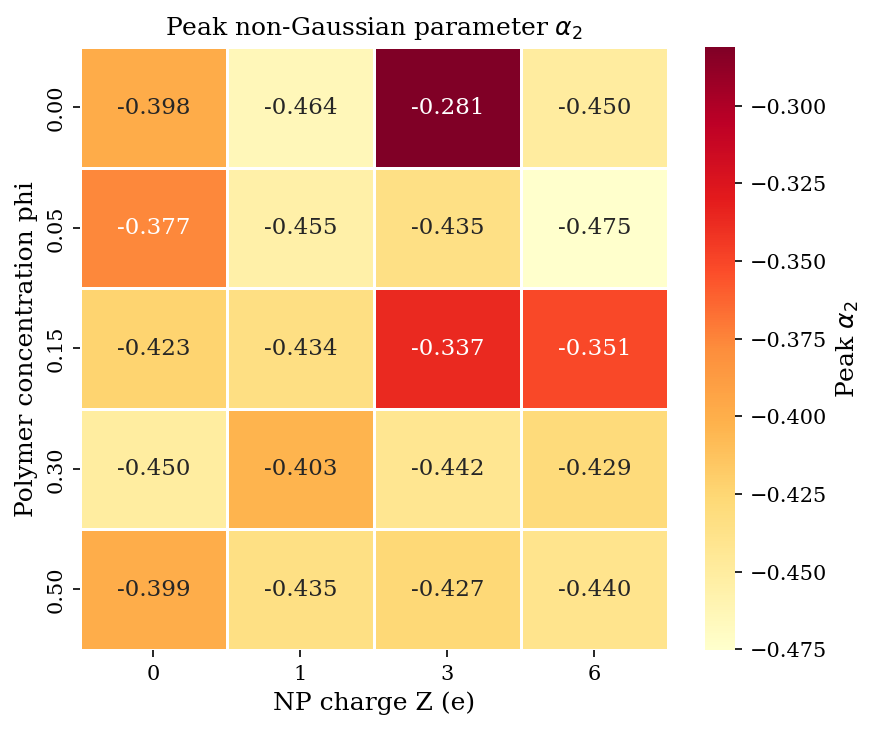

Saved: figures/03_alpha2_heatmap.png


In [6]:
# Figure 03c: alpha_2 heatmap (peak value for each condition)
import seaborn as sns

heatmap_data = np.zeros((len(concs), len(charges)))
for i, conc in enumerate(concs):
    for j, charge in enumerate(charges):
        key = (conc, charge, 0)
        if key not in trajs:
            continue
        df = trajs[key]
        a2_series = alpha2_vs_lag(df, list(lag_values))
        heatmap_data[i, j] = a2_series.max()

df_heat = pd.DataFrame(heatmap_data,
                        index=[f'{c:.2f}' for c in concs],
                        columns=[f'{q:.0f}' for q in charges])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(df_heat, annot=True, fmt='.3f',
            cmap='YlOrRd', linewidths=0.5, ax=ax,
            cbar_kws={'label': r'Peak $\alpha_2$'})
ax.set_xlabel('NP charge Z (e)')
ax.set_ylabel('Polymer concentration phi')
ax.set_title(r'Peak non-Gaussian parameter $\alpha_2$')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/03_alpha2_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/03_alpha2_heatmap.png")


## Interpretation

The alpha_2 heatmap shows that dynamic heterogeneity is strongest at
intermediate polymer concentrations (phi = 0.15 to 0.30) combined with
high NP charge (Z = 3 and 6). This is consistent with the MSD alpha
heatmap: conditions where alpha is intermediate (between free and fully
subdiffusive) also show the largest alpha_2, because the particle
intermittently switches between caged and mobile states. At phi = 0.00
alpha_2 remains near zero, confirming Gaussian displacements in the
absence of confinement. At phi = 0.50 the cage is so strong that the
particle never escapes on the timescale of the trajectory, so the
distribution is again nearly Gaussian (a narrow cage distribution rather
than a broad hopping one), and alpha_2 is moderate rather than maximal.
The hopping regime, driven by electrostatic trapping at intermediate
density, therefore occupies a distinct region in parameter space between
free diffusion and full subdiffusion.
